In [1]:
%pip install qiskit qiskit-ibm-runtime
%pip install qiskit-aer
%pip install 'qiskit[visualization]'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.4/149.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.2/353.2 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.9/434.9 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130

In [2]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
import math
from qiskit.visualization import plot_distribution, plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)


In [3]:
pi = math.pi
q = QuantumRegister(27,'q')
c = ClassicalRegister(3,'c')
qc = QuantumCircuit(q,c)

In [ ]:
QiskitRuntimeService.save_account(channel="ibm_quantum", token="Your Token Here", overwrite=True, set_as_default=True)
service = QiskitRuntimeService(channel='ibm_quantum')
backend = service.least_busy(min_num_qubits=127)

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
circuit_qc = pm.run(qc)
noise_model = NoiseModel.from_backend(backend)


<ipython-input-4-deb46adfd9a1>:2: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, ibm_cloud will be the only valid channel. For information on migrating to the new IBM Quantum Platform on the "ibm_cloud" channel, review the migration guide https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp .
  service = QiskitRuntimeService(channel='ibm_quantum')


Encoding

In [5]:
qc.cx(q[0], q[9])
qc.cx(q[1], q[10])
qc.cx(q[2], q[11])
qc.cx(q[0], q[18])
qc.cx(q[1], q[19])
qc.cx(q[2], q[20])
qc.h(q[0])
qc.h(q[1])
qc.h(q[2])
qc.h(q[9])
qc.h(q[10])
qc.h(q[11])
qc.h(q[18])
qc.h(q[19])
qc.h(q[20])
qc.cx(q[0], q[3])
qc.cx(q[1], q[4])
qc.cx(q[2], q[5])
qc.cx(q[9], q[12])
qc.cx(q[10], q[13])
qc.cx(q[11], q[14])
qc.cx(q[18], q[21])
qc.cx(q[19], q[22])
qc.cx(q[20], q[23])
qc.cx(q[0], q[6])
qc.cx(q[1], q[7])
qc.cx(q[2], q[8])
qc.cx(q[9], q[15])
qc.cx(q[10], q[16])
qc.cx(q[11], q[17])
qc.cx(q[18], q[24])
qc.cx(q[19], q[25])
qc.cx(q[20], q[26])

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=27, num_clbits=0, params=[]), qubits=(<Qubit register=(27, "q"), index=0>, <Qubit register=(27, "q"), index=1>, <Qubit register=(27, "q"), index=2>, <Qubit register=(27, "q"), index=3>, <Qubit register=(27, "q"), index=4>, <Qubit register=(27, "q"), index=5>, <Qubit register=(27, "q"), index=6>, <Qubit register=(27, "q"), index=7>, <Qubit register=(27, "q"), index=8>, <Qubit register=(27, "q"), index=9>, <Qubit register=(27, "q"), index=10>, <Qubit register=(27, "q"), index=11>, <Qubit register=(27, "q"), index=12>, <Qubit register=(27, "q"), index=13>, <Qubit register=(27, "q"), index=14>, <Qubit register=(27, "q"), index=15>, <Qubit register=(27, "q"), index=16>, <Qubit register=(27, "q"), index=17>, <Qubit register=(27, "q"), index=18>, <Qubit register=(27, "q"), index=19>, <Qubit register=(27, "q"), index=20>, <Qubit register=(27, "q"), index=21>, <Qubit register=(27, "q"), index=22>, <Qubit register=(27, "q"), ind

Grover's

In [6]:
qc.h(range(27))

qc.h(q[0])
qc.h(q[1])
qc.h(q[2])
qc.x(q[1])
qc.x(q[2])
qc.ccz(q[0], q[1], q[2])
qc.x(q[1])
qc.x(q[2])
qc.h(q[0])
qc.h(q[1])
qc.h(q[2])
qc.x(q[0])
qc.x(q[1])
qc.x(q[2])
qc.h(q[2])
qc.ccx(q[0], q[1], q[2])
qc.x(q[0])
qc.x(q[1])
qc.h(q[2])
qc.h(q[0])
qc.h(q[1])
qc.x(q[2])
qc.h(q[2])

qc.h(q[3])
qc.h(q[4])
qc.h(q[5])
qc.x(q[4])
qc.x(q[5])
qc.ccz(q[3], q[4], q[5])
qc.x(q[4])
qc.x(q[5])
qc.h(q[3])
qc.h(q[4])
qc.h(q[5])
qc.x(q[3])
qc.x(q[4])
qc.x(q[5])
qc.h(q[5])
qc.ccx(q[3], q[4], q[5])
qc.x(q[3])
qc.x(q[4])
qc.h(q[5])
qc.h(q[3])
qc.h(q[4])
qc.x(q[5])
qc.h(q[5])

qc.h(q[6])
qc.h(q[7])
qc.h(q[8])
qc.x(q[7])
qc.x(q[8])
qc.ccz(q[6], q[7], q[8])
qc.x(q[7])
qc.x(q[8])
qc.h(q[6])
qc.h(q[7])
qc.h(q[8])
qc.x(q[6])
qc.x(q[7])
qc.x(q[8])
qc.h(q[8])
qc.ccx(q[6], q[7], q[8])
qc.x(q[6])
qc.x(q[7])
qc.h(q[8])
qc.h(q[6])
qc.h(q[7])
qc.x(q[8])
qc.h(q[8])

qc.h(q[9])
qc.h(q[10])
qc.h(q[11])
qc.x(q[10])
qc.x(q[11])
qc.ccz(q[9], q[10], q[11])
qc.x(q[10])
qc.x(q[11])
qc.h(q[9])
qc.h(q[10])
qc.h(q[11])
qc.x(q[9])
qc.x(q[10])
qc.x(q[11])
qc.h(q[11])
qc.ccx(q[9], q[10], q[11])
qc.x(q[9])
qc.x(q[10])
qc.h(q[11])
qc.h(q[9])
qc.h(q[10])
qc.x(q[11])
qc.h(q[11])

qc.h(q[12])
qc.h(q[13])
qc.h(q[14])
qc.x(q[13])
qc.x(q[14])
qc.ccz(q[12], q[13], q[14])
qc.x(q[13])
qc.x(q[14])
qc.h(q[12])
qc.h(q[13])
qc.h(q[14])
qc.x(q[12])
qc.x(q[13])
qc.x(q[14])
qc.h(q[14])
qc.ccx(q[12], q[13], q[14])
qc.x(q[12])
qc.x(q[13])
qc.h(q[14])
qc.h(q[12])
qc.h(q[13])
qc.x(q[14])
qc.h(q[14])

qc.h(q[15])
qc.h(q[16])
qc.h(q[17])
qc.x(q[16])
qc.x(q[17])
qc.ccz(q[15], q[16], q[17])
qc.x(q[16])
qc.x(q[17])
qc.h(q[15])
qc.h(q[16])
qc.h(q[17])
qc.x(q[15])
qc.x(q[16])
qc.x(q[17])
qc.h(q[17])
qc.ccx(q[15], q[16], q[17])
qc.x(q[15])
qc.x(q[16])
qc.h(q[17])
qc.h(q[15])
qc.h(q[16])
qc.x(q[17])
qc.h(q[17])

qc.h(q[18])
qc.h(q[19])
qc.h(q[20])
qc.x(q[19])
qc.x(q[20])
qc.ccz(q[18], q[19], q[20])
qc.x(q[19])
qc.x(q[20])
qc.h(q[18])
qc.h(q[19])
qc.h(q[20])
qc.x(q[18])
qc.x(q[19])
qc.x(q[20])
qc.h(q[20])
qc.ccx(q[18], q[19], q[20])
qc.x(q[18])
qc.x(q[19])
qc.h(q[20])
qc.h(q[18])
qc.h(q[19])
qc.x(q[20])
qc.h(q[20])

qc.h(q[21])
qc.h(q[22])
qc.h(q[23])
qc.x(q[22])
qc.x(q[23])
qc.ccz(q[21], q[22], q[23])
qc.x(q[22])
qc.x(q[23])
qc.h(q[21])
qc.h(q[22])
qc.h(q[23])
qc.x(q[21])
qc.x(q[22])
qc.x(q[23])
qc.h(q[23])
qc.ccx(q[21], q[22], q[23])
qc.x(q[21])
qc.x(q[22])
qc.h(q[23])
qc.h(q[21])
qc.h(q[22])
qc.x(q[23])
qc.h(q[23])


qc.h(q[24])
qc.h(q[25])
qc.h(q[26])
qc.x(q[25])
qc.x(q[26])
qc.ccz(q[24], q[25], q[26])
qc.x(q[25])
qc.x(q[26])
qc.h(q[24])
qc.h(q[25])
qc.h(q[26])
qc.x(q[24])
qc.x(q[25])
qc.x(q[26])
qc.h(q[26])
qc.ccx(q[24], q[25], q[26])
qc.x(q[24])
qc.x(q[25])
qc.h(q[26])
qc.h(q[24])
qc.h(q[25])
qc.x(q[26])
qc.h(q[26])

qc.h(range(27))

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=27, num_clbits=0, params=[]), qubits=(<Qubit register=(27, "q"), index=0>, <Qubit register=(27, "q"), index=1>, <Qubit register=(27, "q"), index=2>, <Qubit register=(27, "q"), index=3>, <Qubit register=(27, "q"), index=4>, <Qubit register=(27, "q"), index=5>, <Qubit register=(27, "q"), index=6>, <Qubit register=(27, "q"), index=7>, <Qubit register=(27, "q"), index=8>, <Qubit register=(27, "q"), index=9>, <Qubit register=(27, "q"), index=10>, <Qubit register=(27, "q"), index=11>, <Qubit register=(27, "q"), index=12>, <Qubit register=(27, "q"), index=13>, <Qubit register=(27, "q"), index=14>, <Qubit register=(27, "q"), index=15>, <Qubit register=(27, "q"), index=16>, <Qubit register=(27, "q"), index=17>, <Qubit register=(27, "q"), index=18>, <Qubit register=(27, "q"), index=19>, <Qubit register=(27, "q"), index=20>, <Qubit register=(27, "q"), index=21>, <Qubit register=(27, "q"), index=22>, <Qubit register=(27, "q"), ind

Decoding

In [7]:
qc.cx(q[0], q[3])
qc.cx(q[1], q[4])
qc.cx(q[2], q[5])
qc.cx(q[0], q[6])
qc.cx(q[1], q[7])
qc.cx(q[2], q[8])
qc.cx(q[9], q[12])
qc.cx(q[10], q[13])
qc.cx(q[11], q[14])
qc.cx(q[9], q[15])
qc.cx(q[10], q[16])
qc.cx(q[11], q[17])
qc.cx(q[18], q[21])
qc.cx(q[19], q[22])
qc.cx(q[20], q[23])
qc.cx(q[18], q[24])
qc.cx(q[19], q[25])
qc.cx(q[20], q[26])
qc.ccx(q[6], q[3], q[0])
qc.ccx(q[7], q[4], q[1])
qc.ccx(q[8], q[5], q[2])
qc.ccx(q[15], q[12], q[9])
qc.ccx(q[16], q[13], q[10])
qc.ccx(q[17], q[14], q[11])
qc.ccx(q[24], q[21], q[18])
qc.ccx(q[25], q[22], q[19])
qc.ccx(q[26], q[23], q[20])
qc.h(q[0])
qc.h(q[1])
qc.h(q[2])
qc.h(q[9])
qc.h(q[10])
qc.h(q[11])
qc.h(q[18])
qc.h(q[19])
qc.h(q[20])
qc.cx(q[0], q[9])
qc.cx(q[1], q[10])
qc.cx(q[2], q[11])
qc.cx(q[0], q[18])
qc.cx(q[1], q[19])
qc.cx(q[2], q[20])
qc.ccx(q[18], q[9], q[0])
qc.ccx(q[19], q[10], q[1])
qc.ccx(q[20], q[11], q[2])

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=27, num_clbits=0, params=[]), qubits=(<Qubit register=(27, "q"), index=0>, <Qubit register=(27, "q"), index=1>, <Qubit register=(27, "q"), index=2>, <Qubit register=(27, "q"), index=3>, <Qubit register=(27, "q"), index=4>, <Qubit register=(27, "q"), index=5>, <Qubit register=(27, "q"), index=6>, <Qubit register=(27, "q"), index=7>, <Qubit register=(27, "q"), index=8>, <Qubit register=(27, "q"), index=9>, <Qubit register=(27, "q"), index=10>, <Qubit register=(27, "q"), index=11>, <Qubit register=(27, "q"), index=12>, <Qubit register=(27, "q"), index=13>, <Qubit register=(27, "q"), index=14>, <Qubit register=(27, "q"), index=15>, <Qubit register=(27, "q"), index=16>, <Qubit register=(27, "q"), index=17>, <Qubit register=(27, "q"), index=18>, <Qubit register=(27, "q"), index=19>, <Qubit register=(27, "q"), index=20>, <Qubit register=(27, "q"), index=21>, <Qubit register=(27, "q"), index=22>, <Qubit register=(27, "q"), ind

Measure Logical Qubits

In [8]:
qc.measure(q[0], 0)
qc.measure(q[1], 1)
qc.measure(q[2], 2)

Circuit Drawing

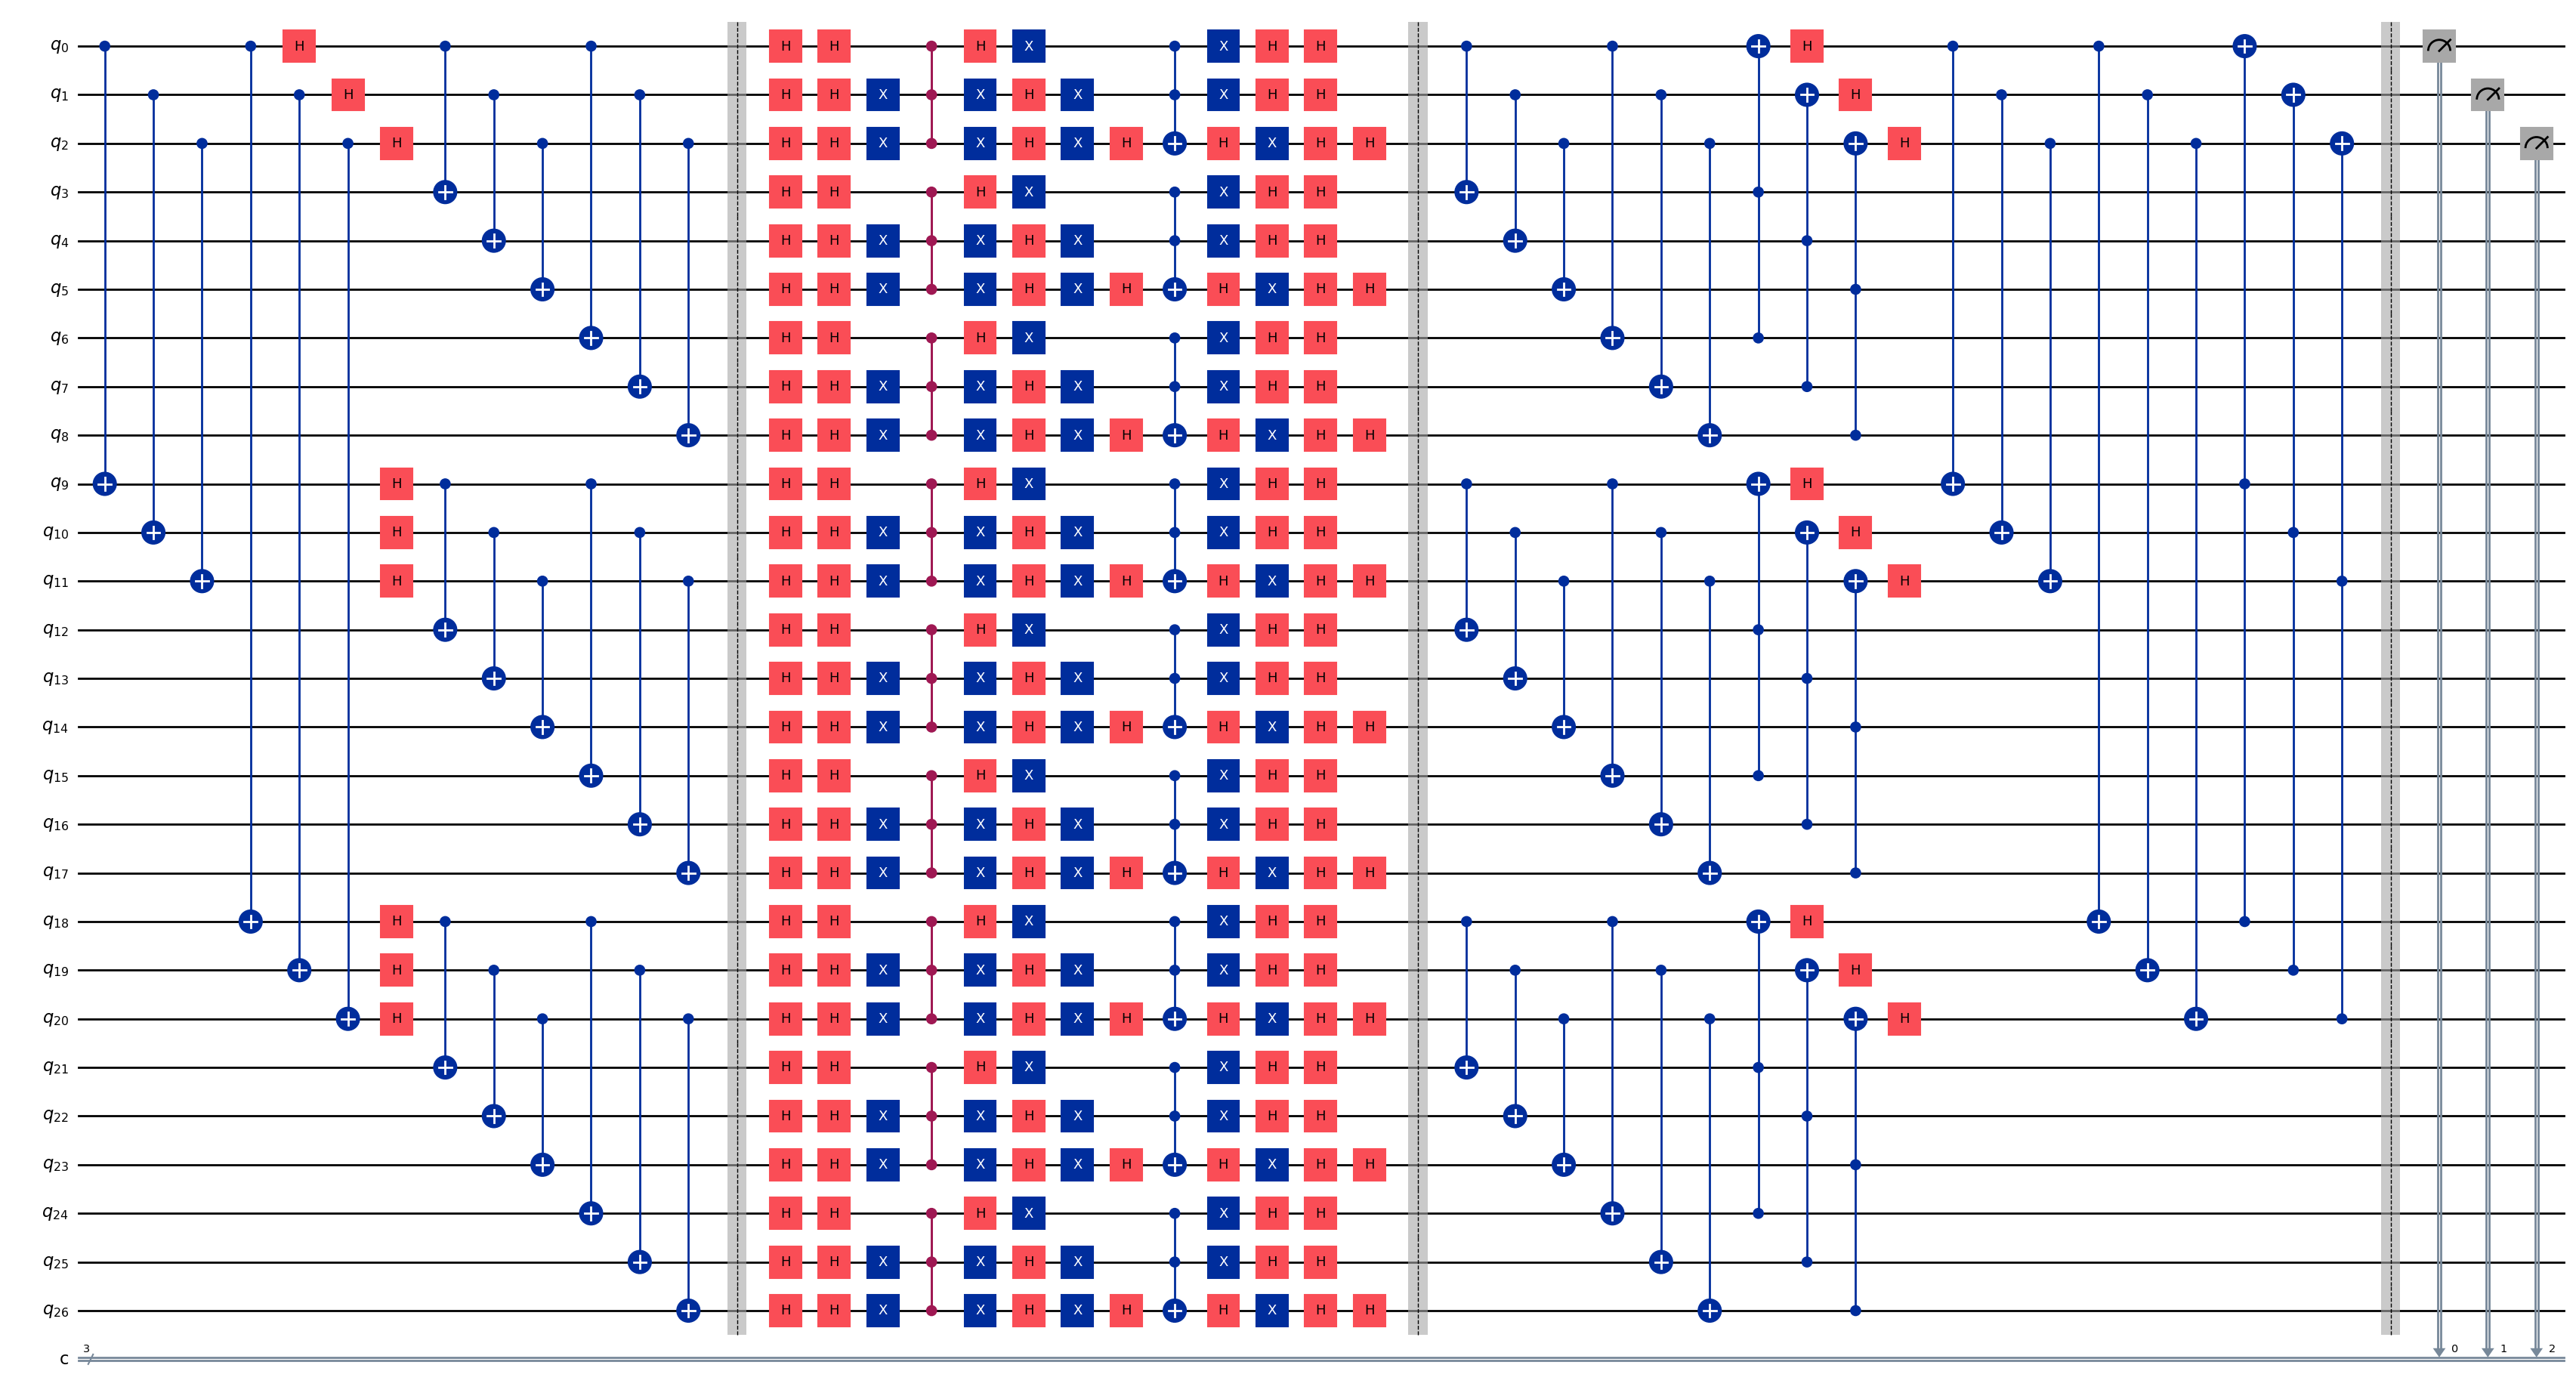

In [9]:
qc.draw('mpl', fold=False, idle_wires=False)

Run Simulation

In [ ]:
simulator = AerSimulator(noise_model=noise_model)
result = simulator.run(qc, shots=128).result()

In [ ]:
counts = result.get_counts(qc)
plot_histogram(counts)

In [10]:
simulator = AerSimulator()
result = simulator.run(qc).result()

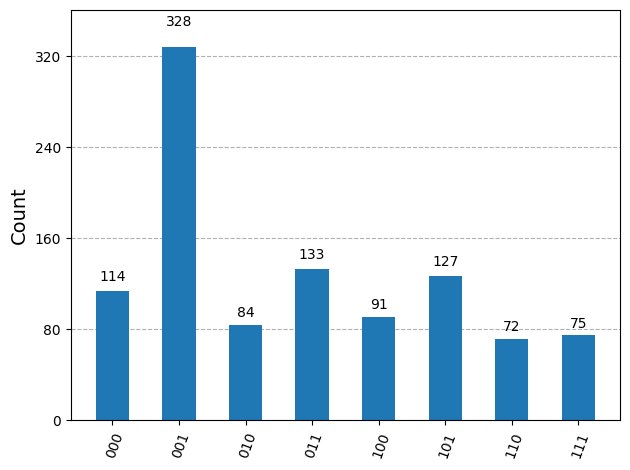

In [11]:
counts = result.get_counts(qc)
plot_histogram(counts)

Run on IBM Quantum Computer

In [ ]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 128
result = sampler.run([circuit_qc]).result()

In [ ]:
dist = result[0].data.c.get_counts()
plot_histogram(dist)